# Deepweeds - EfficientnetV2B0

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2026-02-22 10:07:21.032302: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 10:07:21.032399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 10:07:21.169384: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 3
oversampling = 0 # How many times are we gonna over sample

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
IMG_SIZE=(224,224,3)

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

## Subspace_Bottleneck_FCLayer Config - for Experiment #.5
NUM_SPACES = 16
FINAL_FEAT_SIZE = 1280

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = True
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### Base Model Freezing Part
INIT_LR2 = 2e-5 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-3 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 4 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  676  638  619  614  637  605  644  610  5463 	Total: (10506, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  213  202  215  203  1822 	Total: (3503, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  212  206  204  212  202  215  203  1821 	Total: (3500, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10506 files belonging to 9 classes.
Found 3503 files belonging to 9 classes.
Found 3500 files belonging to 9 classes.


# Sample Images

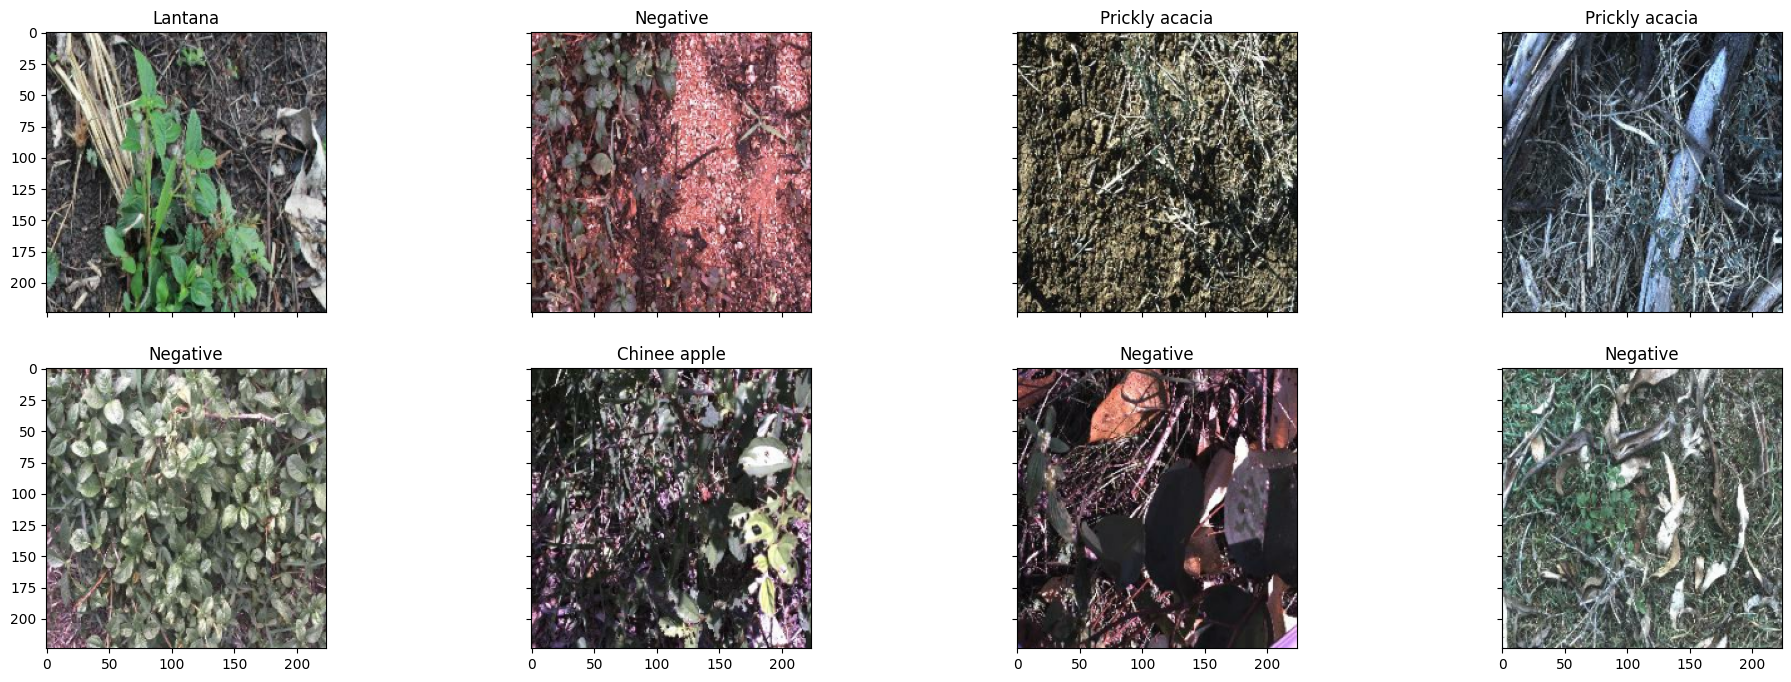

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# ConvSelfAt10tion

In [18]:
class TiledUpSampler2D(tf.keras.layers.Layer):
    def __init__(self, **kwargs): ## pooling method: avg | max
        super().__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 4 ## asserting the input shape is [batch_size, height, width, channel]
        super().build(input_shape)

    def call(self, x):
        shape = x.shape

        pad = shape[2]//2
        t = shape[2] - pad
        w = shape[2] + (2*pad)
        h = shape[1]
        
        _x = tf.tile(x,tf.constant([1,1,3,1]))
        _x = tf.image.crop_to_bounding_box(_x, 0, t, h, w)

        pad = shape[1]//2
        h = shape[1] + (2*pad)
        t = shape[1] - pad
        _x = tf.tile(_x,tf.constant([1,3,1,1]))
        _x = tf.image.crop_to_bounding_box(_x, t, 0, h, w)
        
        return _x


def ConvSelfAt10tion(in_x, dropout=0.05, upsample=True, double_kernel=False):
    avg_x = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(in_x)
    max_x = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(in_x)
    avg_max = tf.keras.layers.Concatenate(axis=-1)([avg_x, max_x])
    x = tf.keras.layers.Dropout(dropout, seed=SEED)(avg_max)

    if upsample and not double_kernel:
        upsampler = TiledUpSampler2D()
        x = upsampler(x)
    
    padding = 'same' if (x.shape[1] == in_x.shape[1] or double_kernel) else 'valid'
    Kernel = (in_x.shape[1]*2) - 1 if double_kernel else in_x.shape[1]
    
    q = tf.keras.layers.Conv2D(1, Kernel, padding=padding, use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED))(x)
    k = tf.keras.layers.Conv2D(in_x.shape[-1], 3, padding='same', activation='sigmoid', groups=in_x.shape[-1], use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED), kernel_regularizer=keras.regularizers.L1L2(0.0001,0.001))(in_x)
    
    x = k * q
    return x

In [19]:
def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024, keep_dims = True):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2

    out_layer = None
    reshape = (n_spaces, -1)
    if keep_dims:
        out_shape = [*in_shape[:-1], -1]
        out_layer = layers.Reshape(out_shape)
        reshape = [*in_shape[:-1], n_spaces, -1]
    else:
        out_layer = layers.Flatten()
    
    bottleneck_layer = keras.Sequential([
        layers.Input(in_shape),
        layers.Reshape(reshape, name="SubspaceFC_Reshape"),
        layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
        layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
        layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.001,0.01), name="SubspaceFC_Bottleneck_Compress"),
        out_layer,
        layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
    ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer

# Building MobileNet Model

In [20]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import ResNet50V2 as resnet
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model

def loadEfficientNetModelForTraining(model):
    base_index = 0
    for i in range(len(model.layers)):
        if('conv' in model.layers[i].name):
            base_index = i
            break

    preprocess_layer = None
    if base_index in [0, 1]:
        model = keras.Model(inputs= model.layers[0].output, outputs=model.layers[-1].output, name = model.name+"_base_")
        return model, preprocess_layer
    else:
        preprocess_layer =  keras.Model(inputs=model.layers[0].output, outputs=model.layers[base_index-1].output, name = "preprocess_layer_"+model.name)
    
    in_layer = model.layers[base_index]
    base_model =  keras.Model(inputs=in_layer.input, outputs=model.layers[-1].output, name = model.name+"_base_")
    return base_model, preprocess_layer
    

def buildModel(IMG_SIZE, skip_preprocess=False, embed_conv_self_attn=False, embed_subspace_fc=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model = EfficientNetV2B0(input_shape=IMG_SIZE, weights='imagenet', include_top=False, include_preprocessing=False)
    # base_model, pre_layer = loadEfficientNetModelForTraining(base_model)
    
    print("Base Model:", base_model.name)
    print(len(base_model.layers))
    # base_model.summary()
    
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')
    x = inputs
    
    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    
    # if embed_conv_self_attn:
    #     _x = layers.Dropout(0.1, seed=SEED)(x) 
    #     x = ConvSelfAt10tion(_x, upsample=False)
        
    x = layers.GlobalAveragePooling2D(keepdims=False)(x)
    x = layers.Dropout(0.3, seed=SEED)(x) 

    # if embed_subspace_fc:
    #     x = subSpaceBottleneckFCLayer(x.shape[1:], NUM_SPACES, FINAL_FEAT_SIZE, False)(x)
    
    outputs = layers.Dense(9, activation='softmax')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [21]:
with strategy.scope():
    model = buildModel(IMG_SIZE, False, False, False)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model: efficientnetv2-b0
268


Model: "augment_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ RR_Bright (RandomBrightness)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Flip (RandomFlip)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Rot (RandomRotation)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Trans (RandomTranslation)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_Zoom (RandomZoom)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RR_GNoise (GaussianNoise)       │ (None, 224, 224, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "DeepWeeds-efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ PP_Resize (Resizing)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ PP_Rescale_down (Rescaling)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_pipeline (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,930,841 (22.62 MB)

 Trainable params: 5,870,233 (22.39 MB)

 Non-trainable params: 60,608 (236.75 KB)

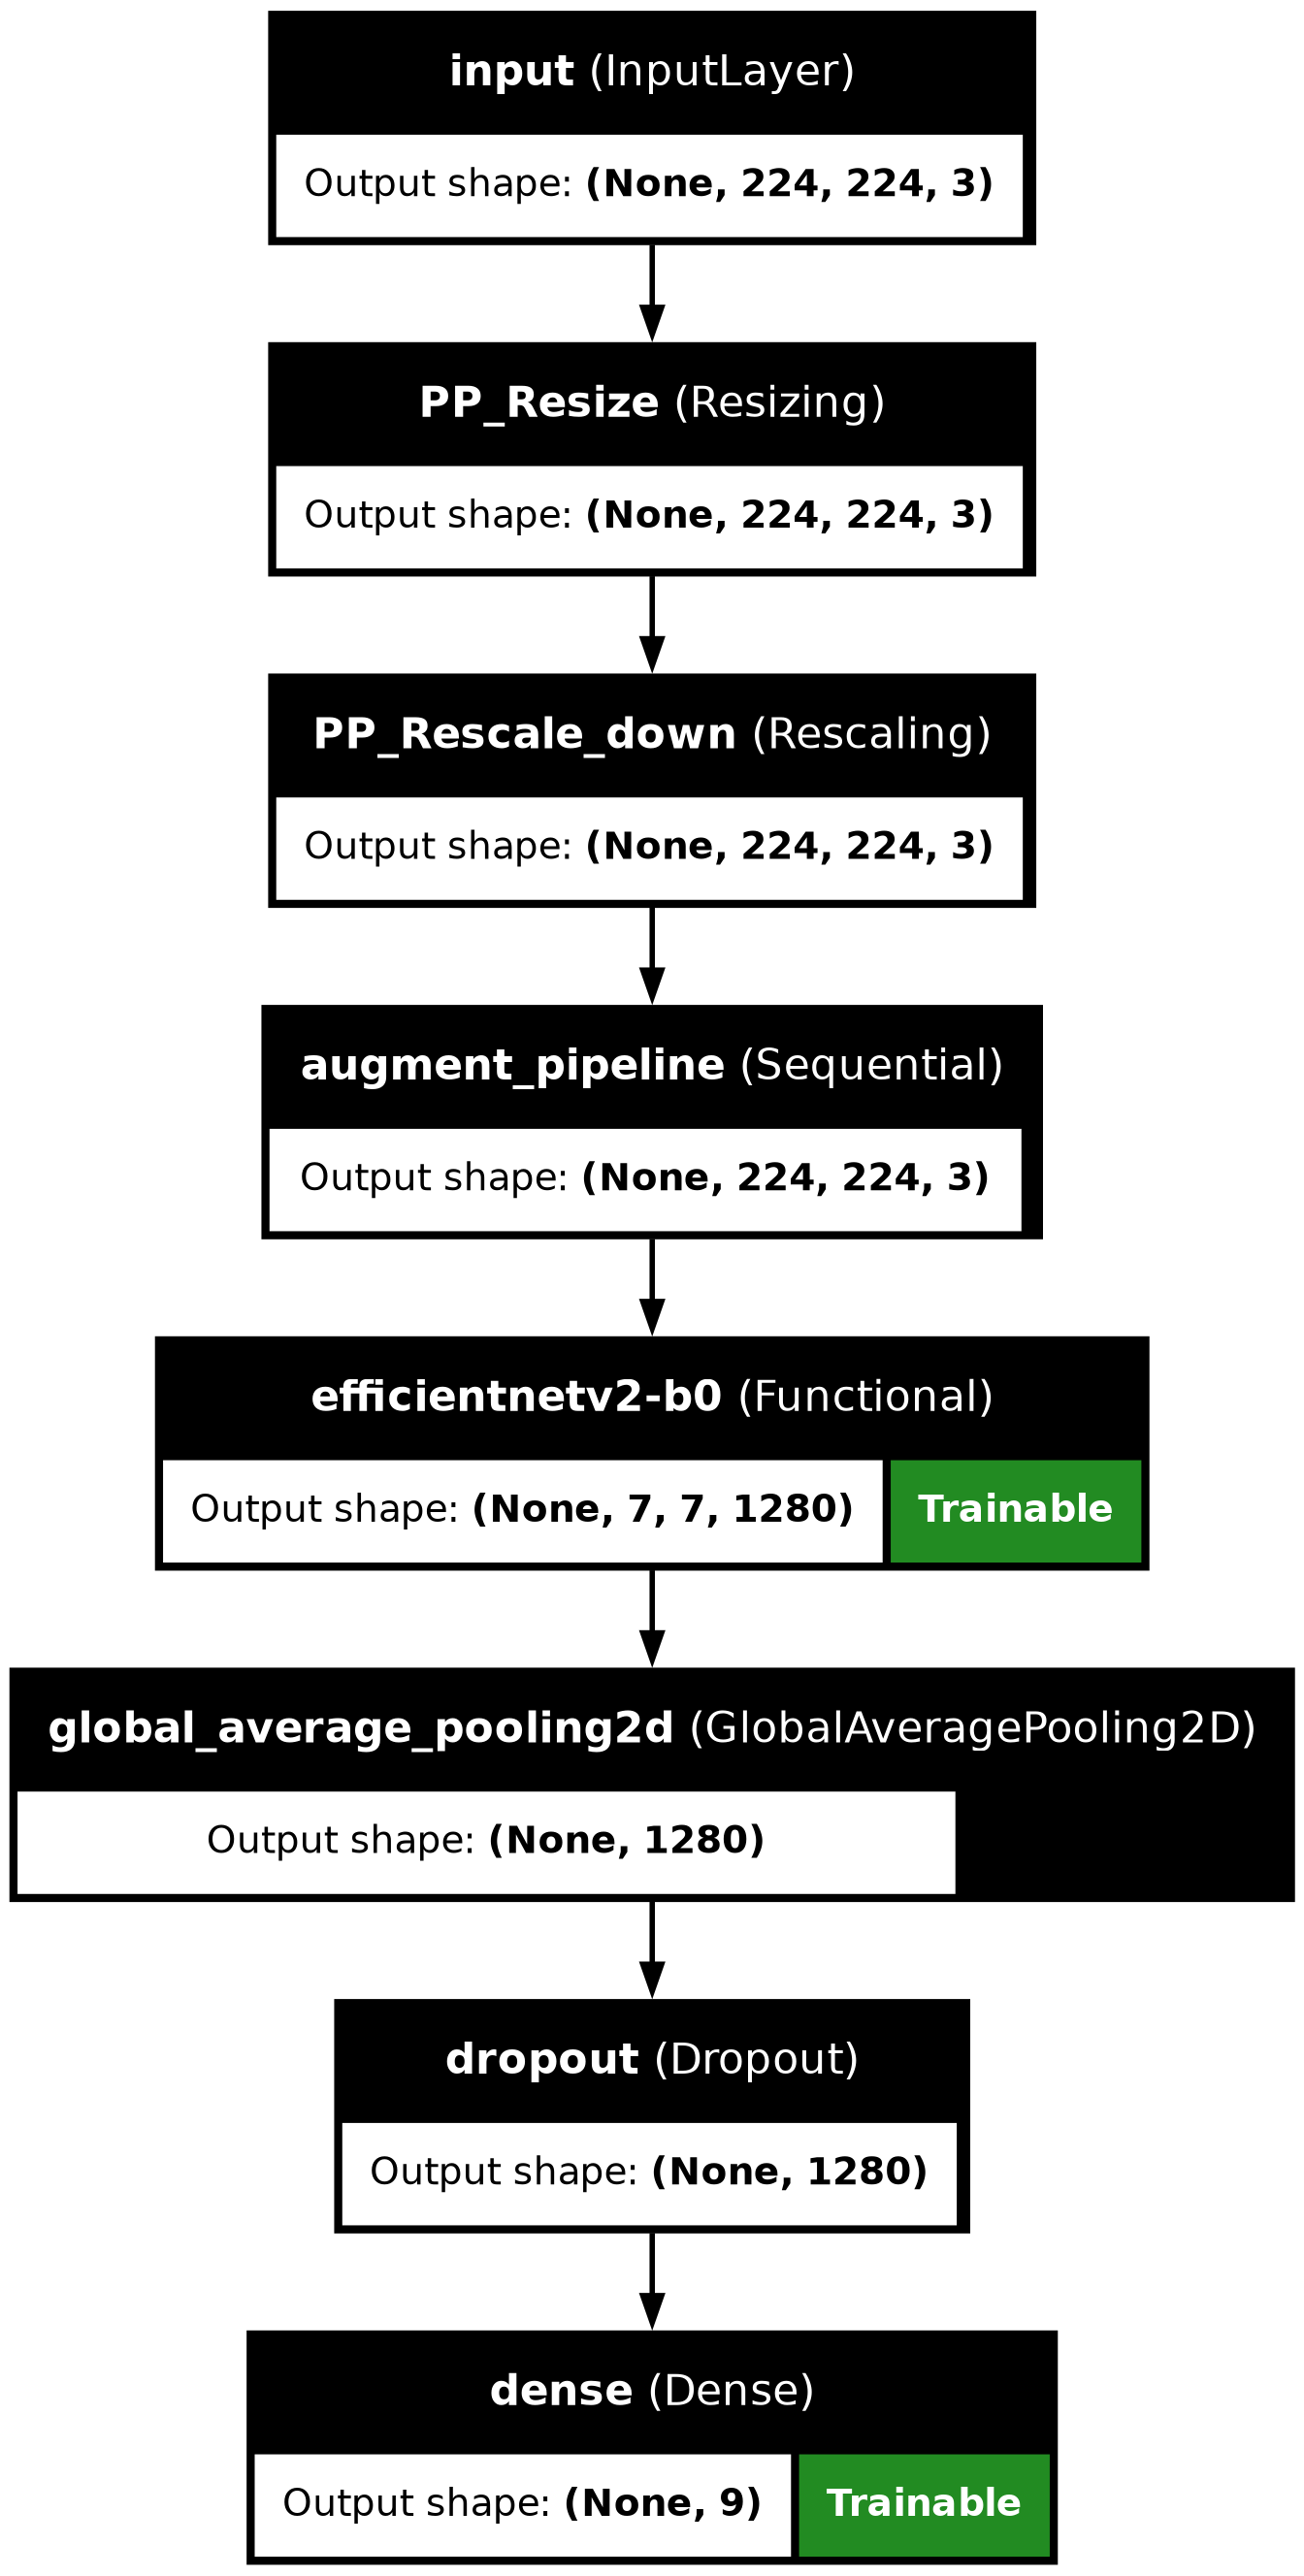

In [22]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [23]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(MODEL_NAME, save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

4
{'name': 'adamw', 'learning_rate': 3.9999998989515007e-05, 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2026-02-22 10:10:06.440573: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepWeeds-efficientnetv2-b0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 ━━━━━━━━━━━━━━━━━━━━ 117s 212ms/step - accuracy: 0.3339 - loss: 0.3582 - val_accuracy: 0.5333 - val_loss: 0.2474 - learning_rate: 5.2000e-05
Epoch 2/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/step - accuracy: 0.6335 - loss: 0.1696 - val_accuracy: 0.6041 - val_loss: 0.1757 - learning_rate: 6.7600e-05
Epoch 3/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 202ms/step - accuracy: 0.7280 - loss: 0.1108 - val_accuracy: 0.7114 - val_loss: 0.1214 - learning_rate: 8.7880e-05
Epoch 4/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/step - accuracy: 0.7802 - loss: 0.0865 - val_accuracy: 0.7848 - val_loss: 0.0853 - learning_rate: 1.1424e-04
Epoch 5/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 202ms/step - accuracy: 0.8100 - loss: 0.0709 - val_accuracy: 0.8153 - val_loss: 0.0699 - learning_rate: 1.4852e-04
Epoch 6/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 202ms/step - accuracy: 0.8376 - loss: 0.0603 - val_accuracy: 0.8179 - val_loss: 0.0658 - learning_rate: 2.0000e-04
Epoch 7/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/

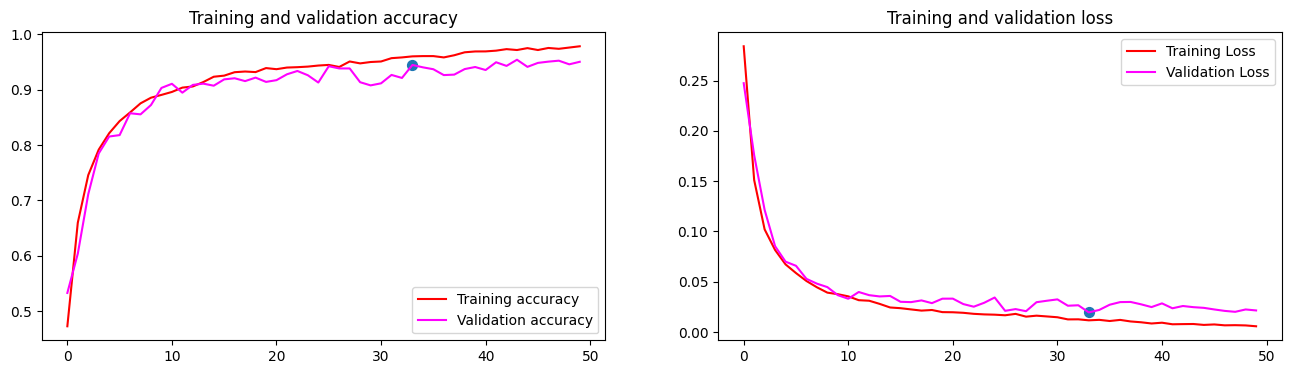

CPU times: user 1h 11min 18s, sys: 7min 57s, total: 1h 19min 16s
Wall time: 55min 56s


In [24]:
%%time
# Train the model
with strategy.scope():
    history1 = model.fit(
          train_generator,
          epochs=EPOCHS,
          validation_data=validation_generator,
          callbacks=callbacks,
        )

    # Plot training results
    plot_loss_acc(history1.history)

# Evaluation#1

In [25]:
# print("\nValidation Set Statistics")
# a, b = eval_model(model, validation_generator)

# print("\nTestn Set Statistics")
# a, b = eval_model(model, test_generator)

# Freezing Base Model

In [26]:
with strategy.scope():
    for layer in model.layers:
        name = layer.name.lower()
        if "efficientnet" in name:
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer efficientnetv2-b0 True


# Evaluations #1.1b

Test After Freezing
Train Set Statistics
model.evaluate
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9799 - loss: 0.0056
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.97579   0.95414   0.96485       676
       Lantana    0.94486   0.99373   0.96868       638
   Parkinsonia    0.97319   0.99677   0.98484       619
    Parthenium    0.97545   0.97068   0.97306       614
Prickly acacia    0.98220   0.95290   0.96733       637
   Rubber vine    0.98829   0.97686   0.98254       605
     Siam weed    0.98765   0.99379   0.99071       644
    Snake weed    0.94896   0.97541   0.96200       610
      Negative    0.98952   0.98499   0.98725      5463

      accuracy                        0.98096     10506
     macro avg    0.97399   0.97770   0.97570     10506
  weighted avg    0.98116   0.98096   0.98098     10506


                False Positive Rate  Accuracy
Chinee apple               0.001628  0.954142
Lantana                    0.003749  0.993730
Parkinsonia                0.001719  0.996769
Parthenium                 0.001516  0.970684
Prickly acacia    

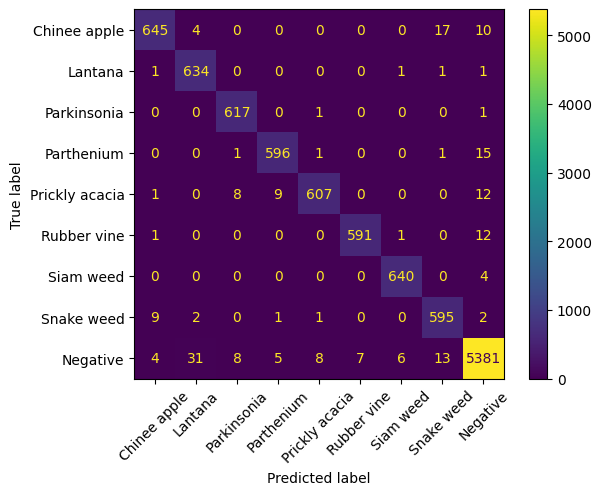

Validation Set Stats
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9446 - loss: 0.0184
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93035   0.83111   0.87793       225
       Lantana    0.87124   0.95305   0.91031       213
   Parkinsonia    0.92273   0.98544   0.95305       206
    Parthenium    0.96875   0.91176   0.93939       204
Prickly acacia    0.93333   0.92019   0.92671       213
   Rubber vine    0.98454   0.94554   0.96465       202
     Siam weed    0.93722   0.97209   0.95434       215
    Snake weed    0.90148   0.90148   0.90148       203
      Negative    0.95785   0.96048   0.95917      1822

      accuracy                        0.94433      3503
     macro avg    0.93417   0.93124   0.93189      3503
  weighted avg    0.94490   0.94433   0.94417      3503


                False Positive Rate  Accuracy
Chinee apple               0.004271  0.831111
Lantana                    0.009119  0.953052
Parkinsonia                0.005156  0.985437
Parthenium                 0.001819  0.911765
Prickly acacia    

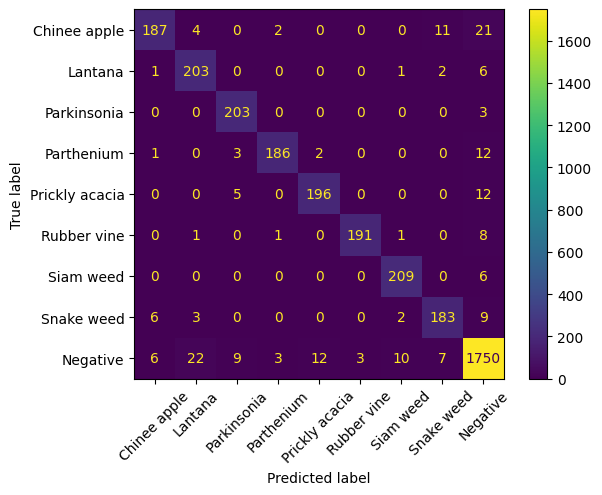

Test Set Stats
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9269 - loss: 0.0326
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.90179   0.89778   0.89978       225
       Lantana    0.89450   0.91981   0.90698       212
   Parkinsonia    0.91781   0.97573   0.94588       206
    Parthenium    0.98469   0.94608   0.96500       204
Prickly acacia    0.94472   0.88679   0.91484       212
   Rubber vine    0.96842   0.91089   0.93878       202
     Siam weed    0.93778   0.98140   0.95909       215
    Snake weed    0.89109   0.88670   0.88889       203
      Negative    0.96223   0.96540   0.96382      1821

      accuracy                        0.94629      3500
     macro avg    0.93367   0.93006   0.93145      3500
  weighted avg    0.94661   0.94629   0.94622      3500


                False Positive Rate  Accuracy
Chinee apple               0.006718  0.897778
Lantana                    0.006995  0.919811
Parkinsonia                0.005464  0.975728
Parthenium                 0.000910  0.946078
Prickly acacia    

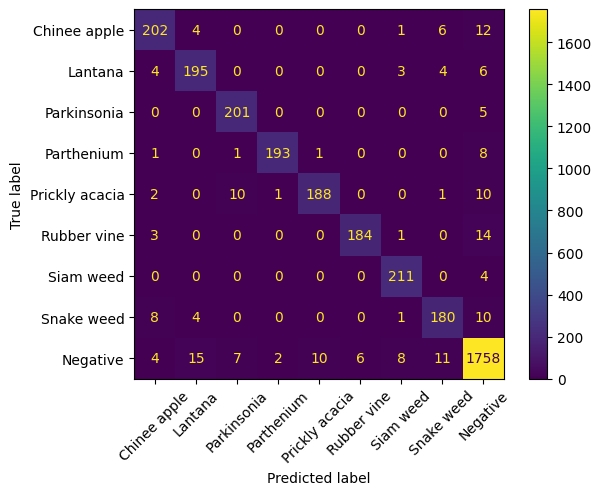

In [27]:
## Test After Freezing
print("Test After Freezing")

print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.76190   0.92444   0.83534       225
       Lantana    0.65781   0.93396   0.77193       212
   Parkinsonia    0.91781   0.97573   0.94588       206
    Parthenium    0.98462   0.94118   0.96241       204
Prickly acacia    0.82979   0.91981   0.87248       212
   Rubber vine    0.95833   0.91089   0.93401       202
     Siam weed    0.93363   0.98140   0.95692       215
    Snake weed    0.89109   0.88670   0.88889       203
      Negative    0.97164   0.88413   0.92582      1821

      accuracy                        0.90829      3500
     macro avg    0.87851   0.92869   0.89930      3500
  weighted avg    0.92037   0.90829   0.91101      3500


                False Positive Rate  Accuracy
Chinee apple               0.019847  0.924444
Lantana                    0.031326  0.933962
Parkinsonia                0.005464  0.975728
Parthenium                 0.000910  0.941176
Prickly acacia    

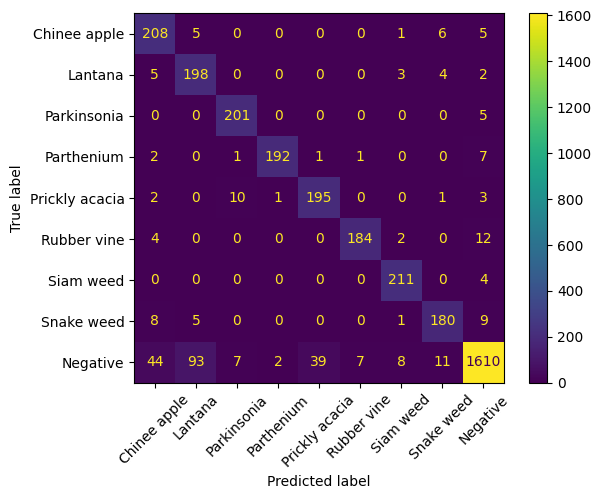

In [28]:
printStats(a,b,0.11)

# Trial 2

In [29]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=2.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
  
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'adamw', 'learning_rate': 1.9999999494757503e-05, 'weight_decay': 0.005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/60


2026-02-22 11:08:59.924779: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/DeepWeeds-efficientnetv2-b0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.9743 - loss: 0.0080 - val_accuracy: 0.9472 - val_loss: 0.0194 - learning_rate: 2.0000e-05
Epoch 2/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9744 - loss: 0.0069 - val_accuracy: 0.9475 - val_loss: 0.0194 - learning_rate: 2.0000e-05
Epoch 3/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9746 - loss: 0.0072 - val_accuracy: 0.9472 - val_loss: 0.0197 - learning_rate: 2.0000e-05
Epoch 4/60
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9815 - loss: 0.0058
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999595806004e-05.
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9815 - loss: 0.0058 - val_accuracy: 0.9480 - val_loss: 0.0196 - learning_rate: 2.0000e-05
Epoch 5/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9784 - loss: 0.0060 - val_accuracy: 0.9478 - val_loss: 0.0201 - learning_rate: 1.6000e-05
Epoch 6/60
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.

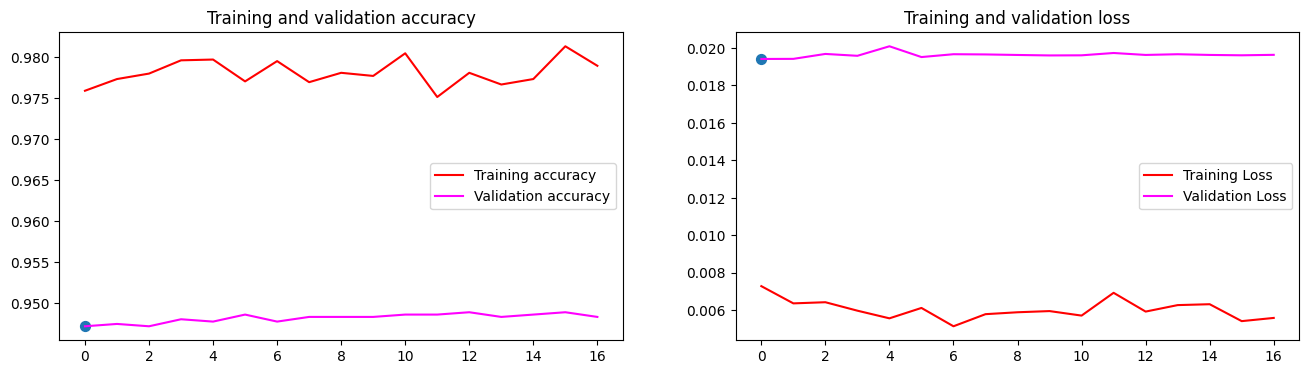

In [30]:
# Train the model

with strategy.scope():
    history2 = model.fit(
          train_generator,
          epochs=EPOCHS//5,
          validation_data=validation_generator,
          callbacks=[early_stopping,reduce_lr]
        )

print("Saving the Checkpoint")
model.save("At10tion-"+MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)

# Accuracy / Loss Plots

Total Epochs: range(0, 67)


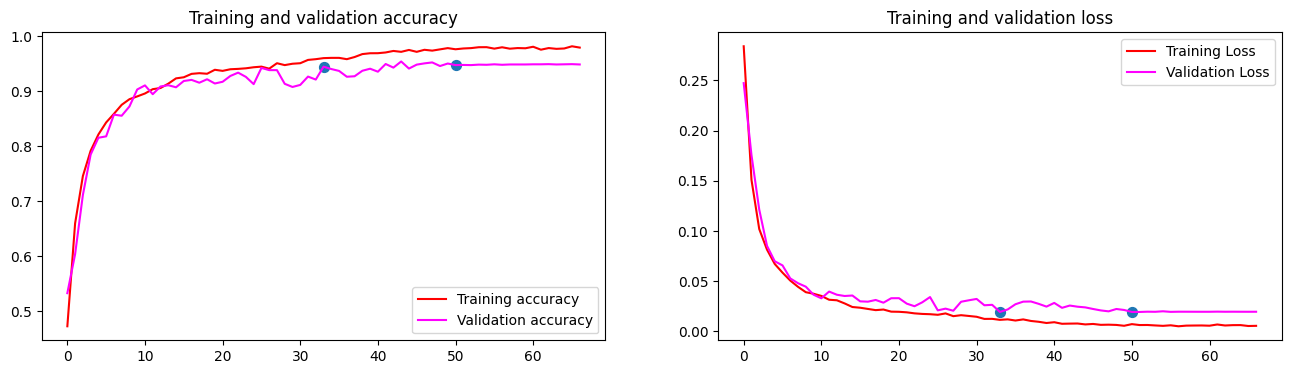

In [31]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 50)


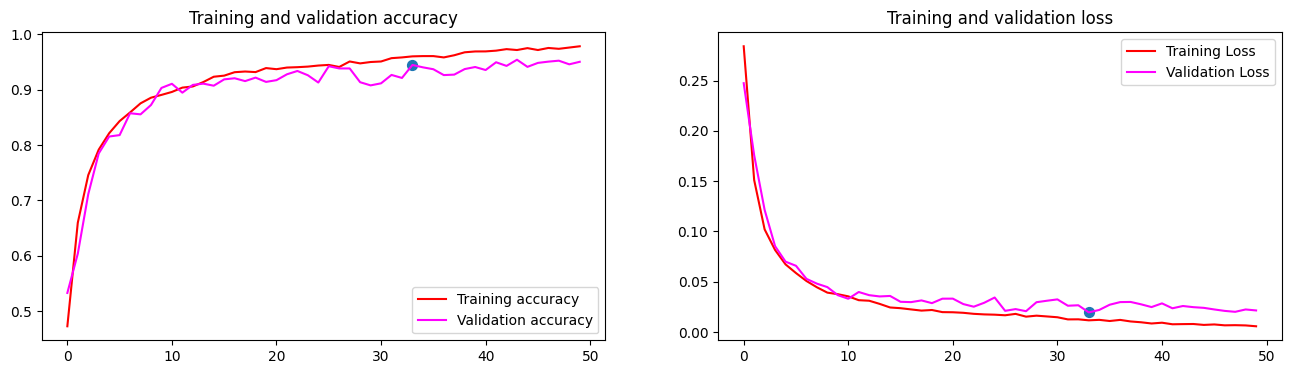

Total Epochs: range(0, 17)


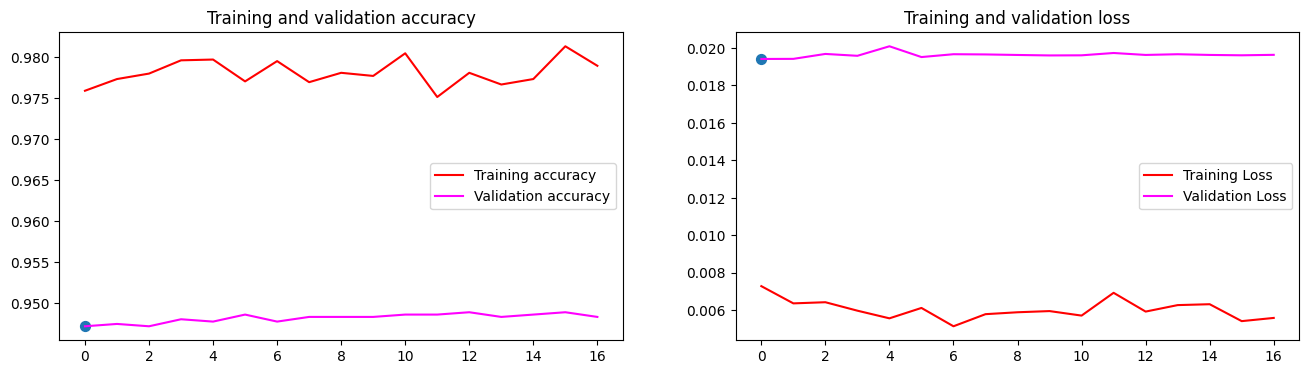

In [32]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9812 - loss: 0.0052
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.97576   0.95266   0.96407       676
       Lantana    0.95626   0.99373   0.97463       638
   Parkinsonia    0.97627   0.99677   0.98641       619
    Parthenium    0.97705   0.97068   0.97386       614
Prickly acacia    0.98537   0.95133   0.96805       637
   Rubber vine    0.98995   0.97686   0.98336       605
     Siam weed    0.98918   0.99379   0.99148       644
    Snake weed    0.95192   0.97377   0.96272       610
      Negative    0.98882   0.98792   0.98837      5463

      accuracy                        0.98220     10506
     macro avg    0.97673   0.97750   0.97700     10506
  weighted avg    0.98231   0.98220   0.98219     10506


                False Positive Rate  Accuracy
Chinee apple               0.001628  0.952663
Lantana                    0.002939  0.993730
Parkinsonia                0.001517  0.996769
Parthenium                 0.001415  0.970684
Prickly acacia    

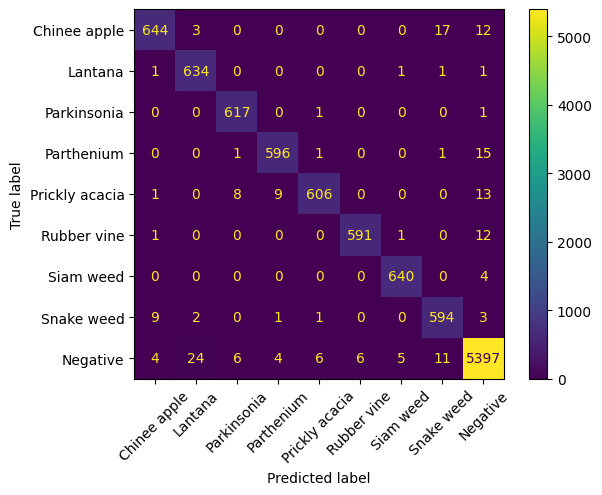


Validation Set Statistics
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9463 - loss: 0.0194
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93035   0.83111   0.87793       225
       Lantana    0.89823   0.95305   0.92483       213
   Parkinsonia    0.92694   0.98544   0.95529       206
    Parthenium    0.97354   0.90196   0.93639       204
Prickly acacia    0.94660   0.91549   0.93079       213
   Rubber vine    0.98454   0.94554   0.96465       202
     Siam weed    0.93694   0.96744   0.95195       215
    Snake weed    0.91500   0.90148   0.90819       203
      Negative    0.95558   0.96817   0.96183      1822

      accuracy                        0.94719      3503
     macro avg    0.94086   0.92996   0.93465      3503
  weighted avg    0.94746   0.94719   0.94689      3503


                False Positive Rate  Accuracy
Chinee apple               0.004271  0.831111
Lantana                    0.006991  0.953052
Parkinsonia                0.004853  0.985437
Parthenium                 0.001516  0.901961
Prickly acacia    

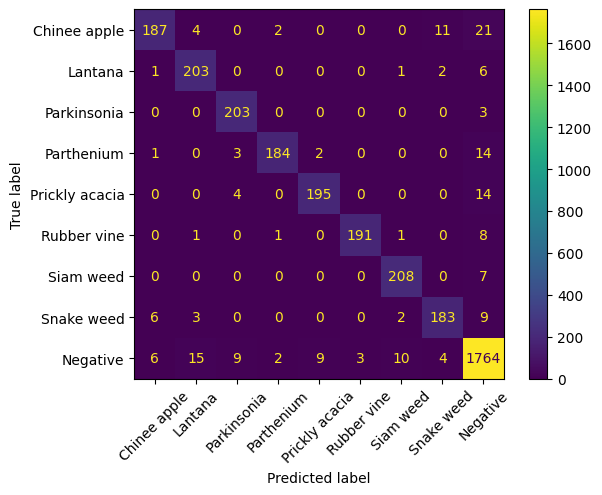


Testn Set Statistics
model.evaluate
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9283 - loss: 0.0330
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.90179   0.89778   0.89978       225
       Lantana    0.91589   0.92453   0.92019       212
   Parkinsonia    0.91781   0.97573   0.94588       206
    Parthenium    0.98969   0.94118   0.96482       204
Prickly acacia    0.94444   0.88208   0.91220       212
   Rubber vine    0.97354   0.91089   0.94118       202
     Siam weed    0.95045   0.98140   0.96568       215
    Snake weed    0.89500   0.88177   0.88834       203
      Negative    0.96087   0.97090   0.96586      1821

      accuracy                        0.94857      3500
     macro avg    0.93883   0.92958   0.93377      3500
  weighted avg    0.94877   0.94857   0.94842      3500


                False Positive Rate  Accuracy
Chinee apple               0.006718  0.897778
Lantana                    0.005474  0.924528
Parkinsonia                0.005464  0.975728
Parthenium                 0.000607  0.941176
Prickly acacia    

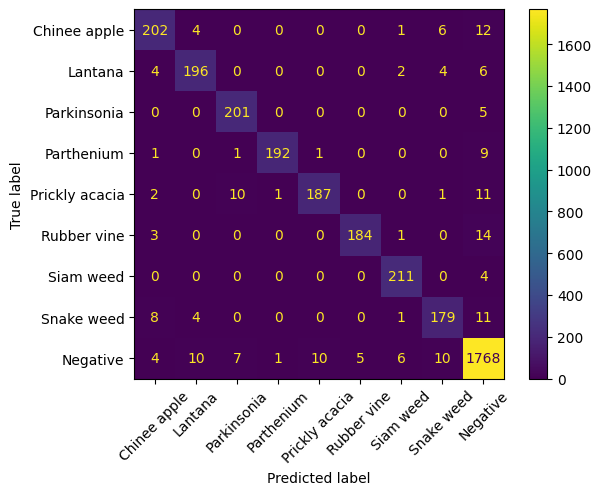

In [33]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.77323   0.92444   0.84211       225
       Lantana    0.66555   0.93868   0.77886       212
   Parkinsonia    0.91781   0.97573   0.94588       206
    Parthenium    0.98964   0.93627   0.96222       204
Prickly acacia    0.82979   0.91981   0.87248       212
   Rubber vine    0.96335   0.91089   0.93639       202
     Siam weed    0.94619   0.98140   0.96347       215
    Snake weed    0.89500   0.88177   0.88834       203
      Negative    0.97068   0.89072   0.92898      1821

      accuracy                        0.91143      3500
     macro avg    0.88347   0.92886   0.90208      3500
  weighted avg    0.92265   0.91143   0.91400      3500


                False Positive Rate  Accuracy
Chinee apple               0.018626  0.924444
Lantana                    0.030414  0.938679
Parkinsonia                0.005464  0.975728
Parthenium                 0.000607  0.936275
Prickly acacia    

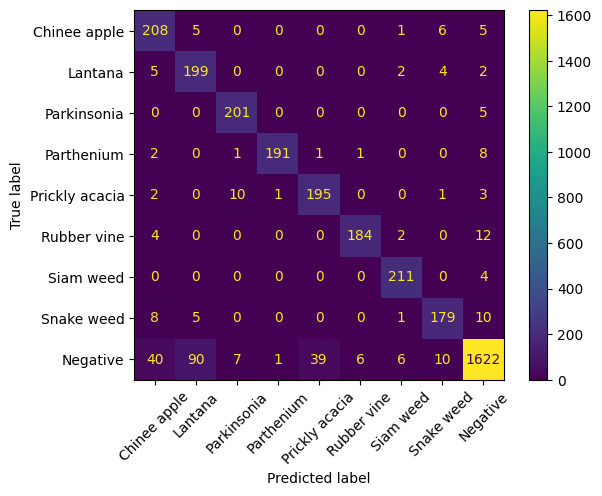

In [34]:
printStats(a,b,0.11)

## Clear Files

In [35]:
shutil.rmtree(base_dir)